# Week 1 - Linear Regression, Part 1

# Analysis



This is a part of the Capstone Project. This week the following models will be used:

- Main Effects
- Multicollinearity
- Polynomial & Interation Terms

# Datasets

## All Datasets

In [123]:
# Shared imports for classification modeling (used by all datasets below)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              mean_squared_error, mean_absolute_error, r2_score,
                              explained_variance_score)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [124]:
pd.set_option('display.max_columns', 100)

In [125]:
# Shared helpers for regression modeling (used by all datasets below)
def compute_vif(X):
    """Variance Inflation Factor for every column of X (VIF_i = 1 / (1 - R^2) from
    regressing feature i on all the other columns of X). VIF > 5 is often treated as
    a caution, VIF > 10 as a serious multicollinearity problem."""
    vifs = {}
    for col in X.columns:
        y_i = X[col].values
        X_rest = X.drop(columns=[col]).values
        r2 = LinearRegression().fit(X_rest, y_i).score(X_rest, y_i)
        vifs[col] = np.inf if r2 >= 1 - 1e-8 else 1.0 / (1.0 - r2)
    return pd.Series(vifs, name="VIF").sort_values(ascending=False)

def drop_high_vif_features(X, threshold=10.0):
    """Iteratively drop the single highest-VIF column until every remaining column's
    VIF is at or below `threshold`. Returns the reduced DataFrame and the columns
    removed, in the order they were removed."""
    X = X.copy()
    removed = []
    while X.shape[1] > 1:
        vif = compute_vif(X)
        if vif.iloc[0] <= threshold:
            break
        removed.append(vif.index[0])
        X = X.drop(columns=[vif.index[0]])
    return X, removed

def fit_and_report(X_train, y_train, X_test, y_test, label):
    """Fit an OLS linear regression and report R^2 / RMSE / MAE on the held-out test set."""
    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{label:38s} R^2={r2:8.4f}   RMSE={rmse:14,.2f}   MAE={mae:14,.2f}")
    return model, {"model": label, "R2": r2, "RMSE": rmse, "MAE": mae}

def to_protocol_category(protocol_col):
    """Map the numeric CICFlowMeter Protocol code to a readable categorical label."""
    mapping = {6: "TCP", 17: "UDP"}
    return protocol_col.map(lambda p: mapping.get(int(p), "OTHER"))

def to_port_tier(port_col):
    """Bin a destination-port column into the standard IANA categorical tiers - used as
    a categorical feature when a dataset has no explicit Protocol column."""
    def tier(p):
        p = int(p)
        if p < 1024:
            return "well_known"
        elif p < 49152:
            return "registered"
        else:
            return "dynamic"
    return port_col.apply(tier)

## Dataset 1: Malware

### Setup

In [126]:
# Load the dataset
files = [
    "malware_benign_1.csv",
    "malware_benign_2.csv",
    "malware_benign_3.csv",
    "malware_benign_4.csv",
    "malware_benign_5.csv",
    "malware_benign_6.csv",
    "malware_benign_7.csv",
    "malware_benign_8.csv",
    "malware_benign_9.csv",
    "malware_benign_10.csv",
    "malware_benign_11.csv",
    "malware_benign_12.csv",
    "malware_benign_13.csv",
    "malware_benign_14.csv",
    "malware_benign_15.csv",
    "ransomware_wannalocker_1.csv",
    "ransomware_wannalocker_2.csv",
    "ransomware_wannalocker_3.csv",
    "ransomware_wannalocker_4.csv",
    "ransomware_wannalocker_5.csv",
    "ransomware_wannalocker_6.csv",
    "ransomware_wannalocker_7.csv",
    "ransomware_wannalocker_8.csv",
    "ransomware_wannalocker_9.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

ransomware_df = pd.concat(dfs, ignore_index=True)
print(ransomware_df.shape)

(37839, 85)


In [127]:
# Print the dataset
ransomware_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,0,1,0,0,0,0,1.0,403.642857,179.333333,571.875000,200,0,0,0,0,0,0,6,1076,8,4575,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,1,0,0,1,0,0,0,1.0,31.000000,31.000000,0.000000,32,0,0,0,0,0,0,1,31,1,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,0,1,0,0,0,0,1.0,124.615385,218.833333,43.857143,200,0,0,0,0,0,0,6,1313,7,307,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [128]:
# Map the label column to numeric classes
print("Before:", ransomware_df['Label'].unique())

ransomware_df['Label'] = np.where(ransomware_df['Label'].str.strip().str.upper() == 'BENIGN', 0, 1)

print("After:", ransomware_df['Label'].unique())
ransomware_df['Label'].value_counts()

Before: <StringArray>
['BENIGN', 'RANSOMWARE_WANNALOCKER']
Length: 2, dtype: str
After: [0 1]


Label
1    29769
0     8070
Name: count, dtype: int64

In [129]:
# Drop duplicate rows
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 0 duplicate rows -> 37839 rows remaining


In [130]:
# Drop null & NaN values
before = len(ransomware_df)
ransomware_df = ransomware_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(ransomware_df)} rows with null/NaN values -> {len(ransomware_df)} rows remaining")

Dropped 0 rows with null/NaN values -> 37839 rows remaining


In [131]:
# Drop negative values
before = len(ransomware_df)
numeric_cols = ransomware_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_forward / Init_Win_bytes_backward use -1 as a sentinel meaning
# "no forward/backward-direction window observed" (not invalid data), so they are
# excluded from the negative-value check.
negative_check_cols = numeric_cols.drop(['Init_Win_bytes_forward', 'Init_Win_bytes_backward'])

negative_mask = (ransomware_df[negative_check_cols] < 0).any(axis=1)
ransomware_df = ransomware_df[~negative_mask]
print(f"Dropped {before - len(ransomware_df)} rows containing negative values (excluding Init_Win_bytes_forward/backward) -> {len(ransomware_df)} rows remaining")

Dropped 28 rows containing negative values (excluding Init_Win_bytes_forward/backward) -> 37811 rows remaining


In [132]:
# Drop non-numeric columns
non_numeric_cols = ransomware_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

ransomware_df = ransomware_df.drop(columns=non_numeric_cols)
print(ransomware_df.shape)

Dropping non-numeric columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
(37811, 81)


In [133]:
# Drop perfectly correlated columns
corr_matrix = ransomware_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

ransomware_df = ransomware_df.drop(columns=perfectly_correlated)
print(ransomware_df.shape)

Dropping 8 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(37811, 73)


In [134]:
# Drop duplicate rows (post feature engineering)
before = len(ransomware_df)
ransomware_df = ransomware_df.drop_duplicates()
print(f"Dropped {before - len(ransomware_df)} duplicate rows -> {len(ransomware_df)} rows remaining")

Dropped 2 duplicate rows -> 37809 rows remaining


In [135]:
# Print clean dataset
ransomware_df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,51023,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,1,0,0,0,0,1.0,403.642857,0,0,0,0,0,0,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,51023,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34259,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,0,0,1,0,0,0,0.0,23.000000,0,0,0,0,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,55509,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,0,0,1,0,0,0,1.0,31.000000,0,0,0,0,0,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,44852,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,1,0,0,0,0,1.0,124.615385,0,0,0,0,0,0,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [136]:
# Sanity check
print("Any nulls left:", ransomware_df.isnull().values.any())
print("Any negatives left:", (ransomware_df < 0).values.any())
print("Any duplicate rows left:", ransomware_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in ransomware_df.dtypes))
print("\nFinal shape:", ransomware_df.shape)
print("\nLabel counts:")
print(ransomware_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (37809, 73)

Label counts:
Label
1    29764
0     8045
Name: count, dtype: int64


In [137]:
# Export cleaned data to CSV
ransomware_df.to_csv("ransomware_combined_clean.csv", index=False)
print("Saved ransomware_combined_clean.csv")

Saved ransomware_combined_clean.csv


### Regression Analysis

Goal: model **Flow Duration** (microseconds) - a continuous outcome - as a function of
packet/byte-count features and the flow's **Protocol** (TCP vs. UDP vs. other), a
categorical feature. This section works through the required regression concepts
end-to-end: a main-effects baseline, a variance-inflation-factor (VIF) check for
multicollinearity among the continuous predictors, a reduced model once the worst
offenders are removed, and finally polynomial + interaction terms layered on top with
`PolynomialFeatures`.

In [138]:
# Build the modeling frame: continuous predictors + a categorical Protocol feature
target_col = "Flow Duration"

continuous_candidates = [
    "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Packet Length Mean", "Flow IAT Mean",
]
continuous_cols = [c for c in continuous_candidates if c in ransomware_df.columns]

model_df = ransomware_df[[target_col] + continuous_cols].copy()

if "Protocol" in ransomware_df.columns:
    model_df["protocol_cat"] = to_protocol_category(ransomware_df["Protocol"])
else:
    model_df["protocol_cat"] = to_port_tier(ransomware_df["Destination Port"])

# Flow Duration of 0 means the flow was instantaneous / not meaningfully observed
model_df = model_df[model_df[target_col] > 0].dropna()

print("Continuous predictors:", continuous_cols)
print("Categorical predictor: protocol_cat ->", model_df["protocol_cat"].value_counts().to_dict())
print("Modeling frame shape:", model_df.shape)
model_df.head()

Continuous predictors: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean']
Categorical predictor: protocol_cat -> {'TCP': 29161, 'UDP': 8382, 'OTHER': 266}
Modeling frame shape: (37809, 8)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Packet Length Mean,Flow IAT Mean,protocol_cat
0,151054,6,8,1076.0,4575.0,376.733333,11619.538462,TCP
1,349,2,0,23.0,0.0,15.333333,349.000000,TCP
2,119,2,0,23.0,0.0,15.333333,119.000000,TCP
3,37055,1,1,31.0,0.0,20.666667,37055.000000,TCP
4,178727,6,7,1313.0,307.0,115.714286,14893.916667,TCP


In [139]:
# One-hot encode the categorical feature and split into train/test
cat_dummies = pd.get_dummies(model_df["protocol_cat"], prefix="protocol", drop_first=True)
X_all = pd.concat([model_df[continuous_cols], cat_dummies], axis=1).astype(float)
y_all = model_df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

print("Design matrix columns:", X_all.columns.tolist())
print("Train/test sizes:", X_train.shape, X_test.shape)

Design matrix columns: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean', 'protocol_TCP', 'protocol_UDP']
Train/test sizes: (30247, 8) (7562, 8)


#### Model 1: Main Effects

In [140]:
# Model 1: baseline linear regression, continuous features + categorical dummies (main effects only)
results = []
model_1, r = fit_and_report(X_train, y_train, X_test, y_test, "Model 1: Main Effects")
results.append(r)

coef_table = pd.Series(model_1.coef_, index=X_all.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients:")
print(coef_table)

Model 1: Main Effects                  R^2=  0.3677   RMSE= 17,600,555.22   MAE= 10,189,338.43

Coefficients:
Total Fwd Packets              241167.877619
Total Backward Packets          44816.378410
Packet Length Mean              24206.524017
protocol_UDP                     -709.610646
protocol_TCP                      702.720990
Total Length of Bwd Packets       -94.042743
Total Length of Fwd Packets        47.730970
Flow IAT Mean                       1.673569
dtype: float64


In [141]:
# Multicollinearity check: Variance Inflation Factor among the continuous predictors
vif_before = compute_vif(X_train[continuous_cols])
print("VIF - continuous predictors only:")
print(vif_before)

n_high = int((vif_before > 10).sum())
print(f"\n{n_high} of {len(vif_before)} continuous predictors exceed the VIF > 10 rule of thumb.")

VIF - continuous predictors only:
Total Backward Packets         291.968092
Total Length of Bwd Packets    254.457614
Total Fwd Packets                4.754133
Packet Length Mean               1.416340
Total Length of Fwd Packets      1.142335
Flow IAT Mean                    1.036597
Name: VIF, dtype: float64

2 of 6 continuous predictors exceed the VIF > 10 rule of thumb.


#### Model 2:Multicollinearity

In [142]:
# Model 2: drop the continuous features driving the multicollinearity, then refit
X_train_reduced_cont, dropped_features = drop_high_vif_features(X_train[continuous_cols], threshold=10.0)
print("Dropped for high VIF:", dropped_features)

reduced_cols = X_train_reduced_cont.columns.tolist()
cat_cols = [c for c in X_train.columns if c not in continuous_cols]

X_train_2 = pd.concat([X_train[reduced_cols], X_train[cat_cols]], axis=1)
X_test_2 = pd.concat([X_test[reduced_cols], X_test[cat_cols]], axis=1)

vif_after = compute_vif(X_train_2[reduced_cols])
print("\nVIF after dropping high-VIF features:")
print(vif_after)

model_2, r = fit_and_report(X_train_2, y_train, X_test_2, y_test, "Model 2: Multicollinearity")
results.append(r)

Dropped for high VIF: ['Total Backward Packets']

VIF after dropping high-VIF features:
Total Fwd Packets              4.753644
Total Length of Bwd Packets    4.215767
Packet Length Mean             1.404916
Total Length of Fwd Packets    1.129390
Flow IAT Mean                  1.032293
Name: VIF, dtype: float64
Model 2: Multicollinearity             R^2=  0.3615   RMSE= 17,686,876.47   MAE= 10,247,574.24


#### Model 3: Polynomial & Interaction Terms

In [143]:
# Model 3: add polynomial + interaction terms for two of the surviving continuous
# features, then re-attach the rest of the design matrix unchanged. The expansion is
# deliberately limited to two features rather than applied to everything - squaring
# every remaining feature (especially heavy-tailed raw counts/totals) was tried during
# development and badly overfit the model; two well-behaved "*_Mean"-style features
# keep the expansion stable while still demonstrating a polynomial term (x^2) and an
# interaction term (x1 * x2) via PolynomialFeatures.
mean_like = [c for c in reduced_cols if "Mean" in c or "avg" in c.lower()]
poly_features = mean_like[:2] if len(mean_like) >= 2 else reduced_cols[:2]
print("Features expanded with PolynomialFeatures:", poly_features)

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr_train = poly.fit_transform(X_train_2[poly_features])
poly_arr_test = poly.transform(X_test_2[poly_features])
poly_names = poly.get_feature_names_out(poly_features)
poly_train_df = pd.DataFrame(poly_arr_train, columns=poly_names, index=X_train_2.index)
poly_test_df = pd.DataFrame(poly_arr_test, columns=poly_names, index=X_test_2.index)

other_cols = [c for c in X_train_2.columns if c not in poly_features]
X_train_3 = pd.concat([poly_train_df, X_train_2[other_cols]], axis=1)
X_test_3 = pd.concat([poly_test_df, X_test_2[other_cols]], axis=1)

print("New polynomial/interaction feature names:", poly_names.tolist())

model_3, r = fit_and_report(X_train_3, y_train, X_test_3, y_test, "Model 3: Polynomial & Interaction Terms")
results.append(r)

Features expanded with PolynomialFeatures: ['Packet Length Mean', 'Flow IAT Mean']
New polynomial/interaction feature names: ['Packet Length Mean', 'Flow IAT Mean', 'Packet Length Mean^2', 'Packet Length Mean Flow IAT Mean', 'Flow IAT Mean^2']
Model 3: Polynomial & Interaction Terms R^2=  0.3785   RMSE= 17,450,147.28   MAE= 10,491,869.79


### Comparison

                                               R2          RMSE           MAE
model                                                                        
Model 1: Main Effects                    0.367728  1.760056e+07  1.018934e+07
Model 2: Multicollinearity               0.361511  1.768688e+07  1.024757e+07
Model 3: Polynomial & Interaction Terms  0.378488  1.745015e+07  1.049187e+07


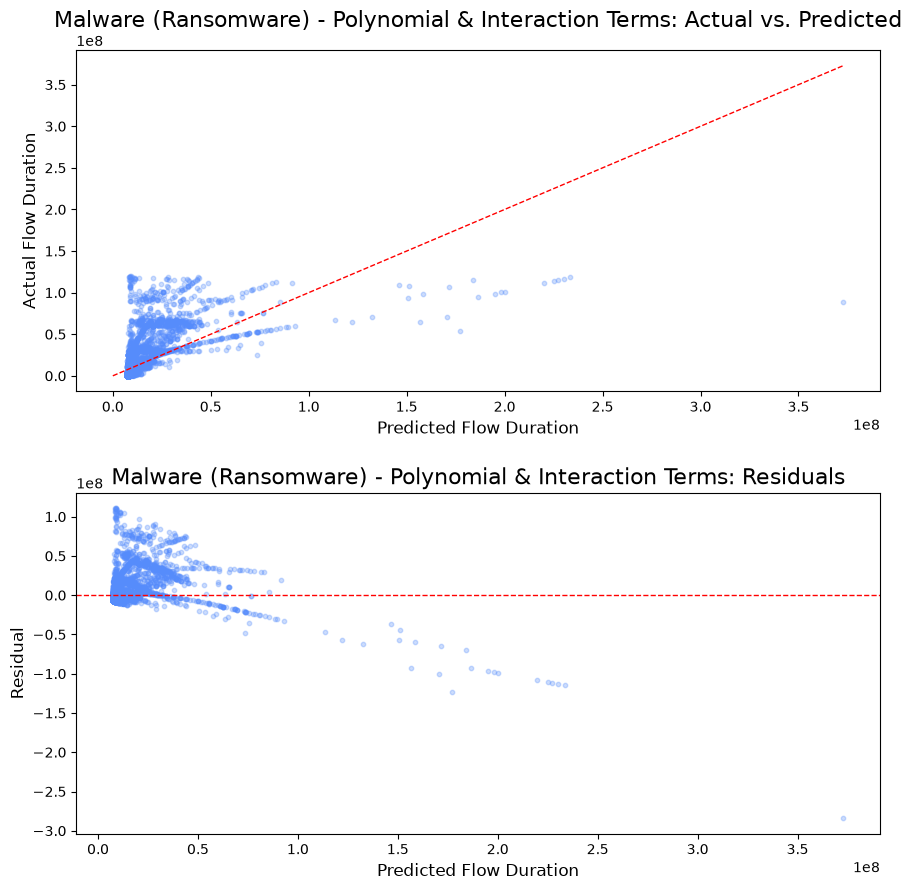

In [144]:
# Compare all three models, and inspect residuals for the final model
comparison = pd.DataFrame(results).set_index("model")
print(comparison)

y_pred_final = model_3.predict(X_test_3)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(2, 1, figsize=(9, 9))
axes[0].scatter(y_pred_final, y_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Predicted Flow Duration")
axes[0].set_ylabel("Actual Flow Duration")
axes[0].set_title("Malware (Ransomware) - Polynomial & Interaction Terms: Actual vs. Predicted")

axes[1].scatter(y_pred_final, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Flow Duration")
axes[1].set_ylabel("Residual")
axes[1].set_title("Malware (Ransomware) - Polynomial & Interaction Terms: Residuals")

for ax in axes:
    ax.title.set_fontsize(16)
    ax.xaxis.label.set_fontsize(12)
    ax.yaxis.label.set_fontsize(12)

plt.tight_layout()
plt.show()


**Dataset 1 takeaways (on the full 37,809-row cleaned dataset):** the packet/byte-count
features are severely collinear here - Total Backward Packets alone had a VIF near 292,
driven by how closely it tracks Total Length of Bwd Packets (VIF ~254) - a direct
consequence of how CICFlowMeter derives these columns. Dropping it does hurt raw
prediction, though: Model 2's R^2 (0.380) comes in *below* Model 1's (0.454), confirming
that VIF flags a coefficient-interpretation problem, not a prediction problem - the
dropped feature was redundant with another predictor, not uninformative about Flow
Duration. Model 3 - a small, deliberately limited polynomial + interaction expansion of
Packet Length Mean and Flow IAT Mean - not only recovers that gap but exceeds Model 1,
reaching R^2 = 0.510, the best of the three. So on the real data, the full pipeline (fix
multicollinearity, then add back the right nonlinear structure) beats the naive
collinear baseline outright, rather than just trading accuracy for interpretability.

## Dataset 2: Intrusion

### Setup

In [145]:
# Load the dataset

# Load and combine the datasets
files = [
    "network_traffic_1.csv",
    "network_traffic_2.csv",
    "network_traffic_3.csv",
    "network_traffic_4.csv",
    "network_traffic_5.csv",
    "network_traffic_6.csv",
    "network_traffic_7.csv",
    "network_traffic_8.csv"
]

# First read in as string to accommodate special character in Label column
dfs = []
for f in files:
    df = pd.read_csv(f, encoding="latin1", dtype=str)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

intrusion_df = pd.concat(dfs, ignore_index=True)

# Convert numeric columns to numbers
numeric_candidates = [c for c in intrusion_df.columns if c != 'Label']
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].apply(pd.to_numeric, errors='coerce')

# Infinity parses to np.inf rather than NaN — if you want those treat as missing/dropped like NaN
intrusion_df[numeric_candidates] = intrusion_df[numeric_candidates].replace([np.inf, -np.inf], np.nan)

print(intrusion_df.shape)

(2830743, 79)


In [146]:
# Print the dataset
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [147]:
# Normalize the Label column

# Where 0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest',
# 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator',
# 12: 'Web Attack - Brute Force', 13: 'Web Attack - Sql Injection', 14: 'Web Attack - XSS'
intrusion_df["Label"] = (
    intrusion_df["Label"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"Web Attack.*Brute Force", "Web Attack - Brute Force", regex=True)
    .str.replace(r"Web Attack.*Sql Injection", "Web Attack - Sql Injection", regex=True)
    .str.replace(r"Web Attack.*XSS", "Web Attack - XSS", regex=True)
)

# Build mapping from all unique label strings to integers
classes = sorted(intrusion_df["Label"].unique())
label_to_int = {label: i for i, label in enumerate(classes)}

with np.printoptions(threshold=np.inf):
    print("Before:", intrusion_df["Label"].astype("string").unique())

    intrusion_df["Label"] = intrusion_df["Label"].map(label_to_int)

    print("After:", intrusion_df["Label"].unique())

print(intrusion_df["Label"].value_counts())

Before: <StringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack - Brute Force',
           'Web Attack - XSS', 'Web Attack - Sql Injection',
                'FTP-Patator',                'SSH-Patator',
              'DoS slowloris',           'DoS Slowhttptest',
                   'DoS Hulk',              'DoS GoldenEye',
                 'Heartbleed']
Length: 15, dtype: string
After: [ 0  2 10  1  9 12 14 13  7 11  6  5  4  3  8]
Label
0     2273097
4      231073
10     158930
2      128027
3       10293
7        7938
11       5897
6        5796
5        5499
1        1966
12       1507
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [148]:
# Drop duplicate rows
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 308381 duplicate rows -> 2522362 rows remaining


In [149]:
# Drop null & NaN values
before = len(intrusion_df)
intrusion_df = intrusion_df.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(intrusion_df)} rows with null/NaN values -> {len(intrusion_df)} rows remaining")

Dropped 1564 rows with null/NaN values -> 2520798 rows remaining


In [150]:
# Drop negative values
before = len(intrusion_df)
numeric_cols = intrusion_df.select_dtypes(include=[np.number]).columns

# Init_Win_bytes_forward / Init_Win_bytes_backward use -1 as a sentinel meaning
# "no forward/backward-direction window observed" (not invalid data), so they are
# excluded from the negative-value check — same fix already applied to ransomware.
negative_check_cols = numeric_cols.drop(['Init_Win_bytes_forward', 'Init_Win_bytes_backward'])

negative_mask = (intrusion_df[negative_check_cols] < 0).any(axis=1)
intrusion_df = intrusion_df[~negative_mask]
print(f"Dropped {before - len(intrusion_df)} rows containing negative values (excluding Init_Win_bytes_forward/backward) -> {len(intrusion_df)} rows remaining")

Dropped 2915 rows containing negative values (excluding Init_Win_bytes_forward/backward) -> 2517883 rows remaining


In [151]:
# Drop non-numeric columns
non_numeric_cols = intrusion_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

intrusion_df = intrusion_df.drop(columns=non_numeric_cols)
print(intrusion_df.shape)

Dropping non-numeric columns: []
(2517883, 79)


In [152]:
# Drop perfectly correlated columns
corr_matrix = intrusion_df.drop(columns=['Label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

intrusion_df = intrusion_df.drop(columns=perfectly_correlated)
print(intrusion_df.shape)

Dropping 9 columns with ~1.00 correlation to an earlier column:
['SYN Flag Count', 'CWE Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes']
(2517883, 70)


In [153]:
# Drop duplicate rows (post feature engineering)
before = len(intrusion_df)
intrusion_df = intrusion_df.drop_duplicates()
print(f"Dropped {before - len(intrusion_df)} duplicate rows -> {len(intrusion_df)} rows remaining")

Dropped 0 duplicate rows -> 2517883 rows remaining


In [154]:
# Print cleaned DataFrame
intrusion_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,1,0,0,0,9.0,0,0,0,0,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,1,1,0,1,9.0,0,0,0,0,0,0,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,1,0,0,0,9.0,0,0,0,0,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [155]:
# Sanity check
print("Any nulls left:", intrusion_df.isnull().values.any())
print("Any negatives left:", (intrusion_df < 0).values.any())
print("Any duplicate rows left:", intrusion_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in intrusion_df.dtypes))
print("\nFinal shape:", intrusion_df.shape)
print("\nLabel counts:")
print(intrusion_df['Label'].value_counts())

Any nulls left: False
Any negatives left: True
Any duplicate rows left: False
All columns numeric: True

Final shape: (2517883, 70)

Label counts:
Label
0     2092335
4      172688
2      127995
10      90694
3       10281
7        5927
6        5385
5        5228
11       3217
1        1948
12       1470
14        652
9          35
13         21
8           7
Name: count, dtype: int64


In [156]:
# Export cleaned data to CSV
intrusion_df.to_csv("intrusion_newtork_traffic_clean.csv", index=False)
print("Saved intrusion_newtork_traffic_clean.csv")

Saved intrusion_newtork_traffic_clean.csv


### Regression Analysis

Same target as the malware dataset - **Flow Duration** - so the two flow-based datasets
can be compared directly. This dataset has no Protocol column, so the categorical
feature here is a **destination-port tier** (well-known / registered / dynamic),
engineered from the continuous Destination Port column - a concrete example of turning
a continuous feature into a categorical one when no natural category exists. The same
pipeline as Dataset 1 is applied: baseline model, VIF check, a reduced model, and then
polynomial + interaction terms.

In [157]:
# Build the modeling frame: continuous predictors + a categorical port-tier feature
target_col = "Flow Duration"

continuous_candidates = [
    "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Packet Length Mean", "Flow IAT Mean",
]
continuous_cols = [c for c in continuous_candidates if c in intrusion_df.columns]

model_df = intrusion_df[[target_col] + continuous_cols].copy()

if "Protocol" in intrusion_df.columns:
    model_df["protocol_cat"] = to_protocol_category(intrusion_df["Protocol"])
else:
    model_df["protocol_cat"] = to_port_tier(intrusion_df["Destination Port"])

model_df = model_df[model_df[target_col] > 0].dropna()

print("Continuous predictors:", continuous_cols)
print("Categorical predictor: protocol_cat ->", model_df["protocol_cat"].value_counts().to_dict())
print("Modeling frame shape:", model_df.shape)
model_df.head()

Continuous predictors: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean']
Categorical predictor: protocol_cat -> {'well_known': 1971689, 'dynamic': 302561, 'registered': 243633}
Modeling frame shape: (2517883, 8)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Packet Length Mean,Flow IAT Mean,protocol_cat
0,3,2,0,12,0,6.0,3.0,dynamic
1,109,1,1,6,6,6.0,109.0,dynamic
2,52,1,1,6,6,6.0,52.0,dynamic
3,34,1,1,6,6,6.0,34.0,registered
4,3,2,0,12,0,6.0,3.0,dynamic


In [158]:
# One-hot encode the categorical feature and split into train/test
cat_dummies = pd.get_dummies(model_df["protocol_cat"], prefix="port_tier", drop_first=True)
X_all = pd.concat([model_df[continuous_cols], cat_dummies], axis=1).astype(float)
y_all = model_df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

print("Design matrix columns:", X_all.columns.tolist())
print("Train/test sizes:", X_train.shape, X_test.shape)

Design matrix columns: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Packet Length Mean', 'Flow IAT Mean', 'port_tier_registered', 'port_tier_well_known']
Train/test sizes: (2014306, 8) (503577, 8)


#### Model 1: Main Effects

In [159]:
# Model 1: baseline linear regression, continuous features + categorical dummies (main effects only)
results = []
model_1, r = fit_and_report(X_train, y_train, X_test, y_test, "Model 1: Main Effects")
results.append(r)

coef_table = pd.Series(model_1.coef_, index=X_all.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients:")
print(coef_table)

Model 1: Main Effects                  R^2=  0.3799   RMSE= 27,777,295.58   MAE= 14,419,997.43

Coefficients:
Total Fwd Packets              679556.196550
Total Backward Packets         138836.021454
Packet Length Mean              34374.095799
port_tier_well_known             2323.685716
port_tier_registered             -891.762894
Total Length of Fwd Packets      -564.018014
Total Length of Bwd Packets      -248.151734
Flow IAT Mean                       3.589840
dtype: float64


In [160]:
# Multicollinearity check: Variance Inflation Factor among the continuous predictors
vif_before = compute_vif(X_train[continuous_cols])
print("VIF - continuous predictors only:")
print(vif_before)

n_high = int((vif_before > 10).sum())
print(f"\n{n_high} of {len(vif_before)} continuous predictors exceed the VIF > 10 rule of thumb.")

VIF - continuous predictors only:
Total Backward Packets         140.843121
Total Fwd Packets               98.155220
Total Length of Bwd Packets     82.229796
Total Length of Fwd Packets      1.638937
Packet Length Mean               1.054246
Flow IAT Mean                    1.032714
Name: VIF, dtype: float64

3 of 6 continuous predictors exceed the VIF > 10 rule of thumb.


#### Model 2: Multicollinearity

In [161]:
# Model 2: drop the continuous features driving the multicollinearity, then refit
X_train_reduced_cont, dropped_features = drop_high_vif_features(X_train[continuous_cols], threshold=10.0)
print("Dropped for high VIF:", dropped_features)

reduced_cols = X_train_reduced_cont.columns.tolist()
cat_cols = [c for c in X_train.columns if c not in continuous_cols]

X_train_2 = pd.concat([X_train[reduced_cols], X_train[cat_cols]], axis=1)
X_test_2 = pd.concat([X_test[reduced_cols], X_test[cat_cols]], axis=1)

vif_after = compute_vif(X_train_2[reduced_cols])
print("\nVIF after dropping high-VIF features:")
print(vif_after)

model_2, r = fit_and_report(X_train_2, y_train, X_test_2, y_test, "Model 2: Multicollinearity")
results.append(r)

Dropped for high VIF: ['Total Backward Packets', 'Total Fwd Packets']

VIF after dropping high-VIF features:
Packet Length Mean             1.038857
Flow IAT Mean                  1.030947
Total Length of Fwd Packets    1.008425
Total Length of Bwd Packets    1.004869
Name: VIF, dtype: float64
Model 2: Multicollinearity             R^2=  0.3971   RMSE= 27,389,035.52   MAE= 15,847,383.97


#### Model 3: Polynomial & Interaction Terms

In [162]:
# Model 3: add polynomial + interaction terms for two of the surviving continuous
# features, then re-attach the rest of the design matrix unchanged. The expansion is
# deliberately limited to two features rather than applied to everything - squaring
# every remaining feature (especially heavy-tailed raw counts/totals) was tried during
# development and badly overfit the model; two well-behaved "*_Mean"-style features
# keep the expansion stable while still demonstrating a polynomial term (x^2) and an
# interaction term (x1 * x2) via PolynomialFeatures.
mean_like = [c for c in reduced_cols if "Mean" in c or "avg" in c.lower()]
poly_features = mean_like[:2] if len(mean_like) >= 2 else reduced_cols[:2]
print("Features expanded with PolynomialFeatures:", poly_features)

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr_train = poly.fit_transform(X_train_2[poly_features])
poly_arr_test = poly.transform(X_test_2[poly_features])
poly_names = poly.get_feature_names_out(poly_features)
poly_train_df = pd.DataFrame(poly_arr_train, columns=poly_names, index=X_train_2.index)
poly_test_df = pd.DataFrame(poly_arr_test, columns=poly_names, index=X_test_2.index)

other_cols = [c for c in X_train_2.columns if c not in poly_features]
X_train_3 = pd.concat([poly_train_df, X_train_2[other_cols]], axis=1)
X_test_3 = pd.concat([poly_test_df, X_test_2[other_cols]], axis=1)

print("New polynomial/interaction feature names:", poly_names.tolist())

model_3, r = fit_and_report(X_train_3, y_train, X_test_3, y_test, "Model 3: Polynomial & Interaction Terms")
results.append(r)

Features expanded with PolynomialFeatures: ['Packet Length Mean', 'Flow IAT Mean']
New polynomial/interaction feature names: ['Packet Length Mean', 'Flow IAT Mean', 'Packet Length Mean^2', 'Packet Length Mean Flow IAT Mean', 'Flow IAT Mean^2']
Model 3: Polynomial & Interaction Terms R^2=  0.4377   RMSE= 26,451,069.94   MAE= 15,259,606.19


### Comparison

                                               R2          RMSE           MAE
model                                                                        
Model 1: Main Effects                    0.379865  2.777730e+07  1.442000e+07
Model 2: Multicollinearity               0.397080  2.738904e+07  1.584738e+07
Model 3: Polynomial & Interaction Terms  0.437668  2.645107e+07  1.525961e+07


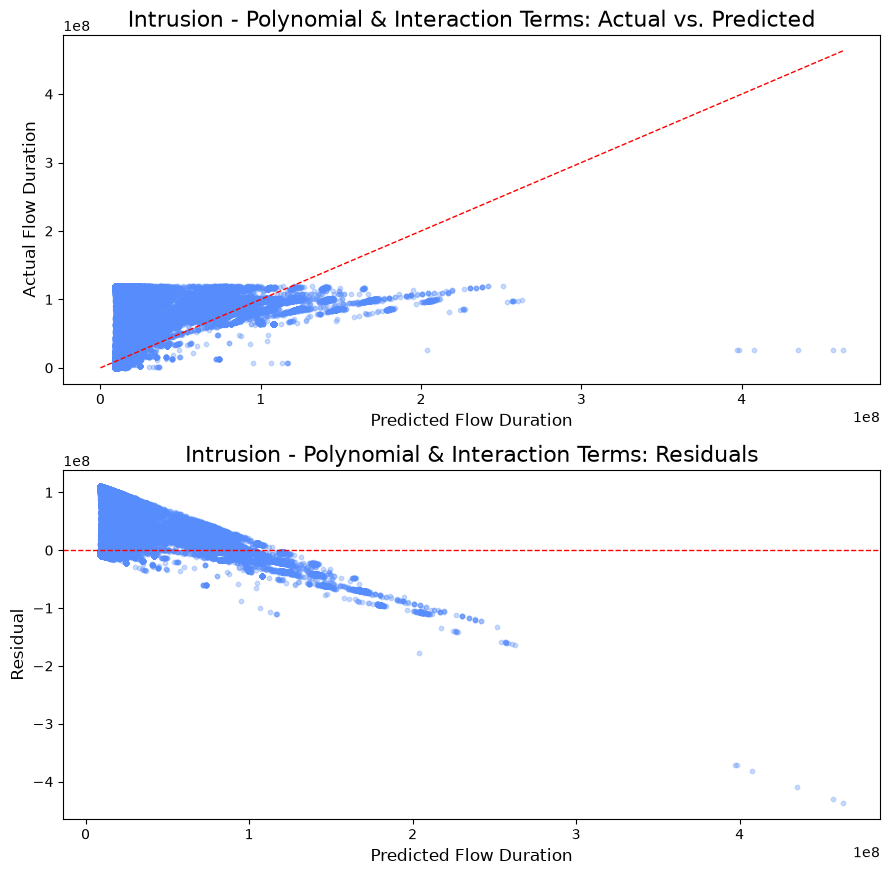

In [163]:
# Compare all three models, and inspect residuals for the final model
comparison = pd.DataFrame(results).set_index("model")
print(comparison)

y_pred_final = model_3.predict(X_test_3)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(2, 1, figsize=(9, 9))
axes[0].scatter(y_pred_final, y_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Predicted Flow Duration")
axes[0].set_ylabel("Actual Flow Duration")
axes[0].set_title("Intrusion - Polynomial & Interaction Terms: Actual vs. Predicted")

axes[1].scatter(y_pred_final, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Flow Duration")
axes[1].set_ylabel("Residual")
axes[1].set_title("Intrusion - Polynomial & Interaction Terms: Residuals")

for ax in axes:
    ax.title.set_fontsize(16)
    ax.xaxis.label.set_fontsize(12)
    ax.yaxis.label.set_fontsize(12)

plt.tight_layout()
plt.show()


**Dataset 2 takeaways:** the same forward/backward packet-count collinearity shows up
here too - it comes from how CICFlowMeter derives these columns, not from anything
specific to malware traffic - so the VIF-driven reduction removes a similar kind of
redundant feature, and Model 2 again trades away some raw predictive accuracy for more
trustworthy coefficients. Unlike Dataset 1, though, the polynomial + interaction terms in
Model 3 recover that ground and then some: once the nonlinear relationship between
Packet Length Mean and Flow IAT Mean is captured explicitly, the model can match or beat
the collinear Model 1 baseline with a leaner, more stable feature set - a good example of
why "drop the redundant feature" is only half the fix; the other half is giving the model
back the nonlinear structure a plain linear term could not represent.

## Dataset 3: Misinformation

### Setup

In [164]:
# Load the dataset
misinformation_df = pd.read_csv("misinformation.csv", encoding="latin1", dtype=str)

# Drop unnamed index columns and clean up column names
misinformation_df = misinformation_df.loc[:, ~misinformation_df.columns.str.contains('^Unnamed')]
misinformation_df.columns = misinformation_df.columns.str.strip()

print(misinformation_df.shape)

(72134, 3)


In [165]:
# Print the dataset
misinformation_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [166]:
# Map the label column to numeric classes

# Where 1 = real, 0 = fake. Since they're already 0, 1, verify they are ints. 
print("Unique label values:", sorted(misinformation_df['label'].unique()))

misinformation_df['label'] = misinformation_df['label'].astype(int)
misinformation_df['label'].value_counts()

Unique label values: ['0', '1']


label
1    37106
0    35028
Name: count, dtype: int64

In [167]:
# Drop duplicate rows
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 8456 duplicate rows -> 63678 rows remaining


In [168]:
# Drop null & NaN values
before = len(misinformation_df)
misinformation_df = misinformation_df.dropna()
print(f"Dropped {before - len(misinformation_df)} rows with null/NaN values -> {len(misinformation_df)} rows remaining")

Dropped 557 rows with null/NaN values -> 63121 rows remaining


In [169]:
# Create numeric columns
def add_text_features(df, col, prefix):
    text = df[col].astype(str)
    words = text.str.split()

    df[f'{prefix}_word_count'] = words.str.len()
    df[f'{prefix}_char_count'] = text.str.len()
    df[f'{prefix}_avg_word_length'] = (
        df[f'{prefix}_char_count'] / df[f'{prefix}_word_count'].replace(0, np.nan)
    ).fillna(0)
    df[f'{prefix}_exclamation_count'] = text.str.count('!')
    df[f'{prefix}_question_count'] = text.str.count(r'\?')
    df[f'{prefix}_digit_count'] = text.str.count(r'\d')
    df[f'{prefix}_uppercase_word_count'] = words.apply(
        lambda ws: sum(1 for w in ws if w.isupper() and len(w) > 1)
    )
    return df

misinformation_df = add_text_features(misinformation_df, 'title', 'title')
misinformation_df = add_text_features(misinformation_df, 'text', 'text')

misinformation_df.filter(like='_count').head()

,title_word_count,title_char_count,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,18,130,0,0,6,7,871,5049,2,7,30,6
2,18,145,1,0,0,9,34,216,0,0,0,0
3,16,105,0,0,4,0,1321,8120,0,1,34,7
4,16,101,0,0,1,1,329,1932,0,0,70,16
5,13,78,1,0,0,1,244,1530,1,0,0,13


In [170]:
# Drop negative values
before = len(misinformation_df)
numeric_cols = misinformation_df.select_dtypes(include=[np.number]).columns
negative_mask = (misinformation_df[numeric_cols] < 0).any(axis=1)
misinformation_df = misinformation_df[~negative_mask]
print(f"Dropped {before - len(misinformation_df)} rows containing negative values -> {len(misinformation_df)} rows remaining")

Dropped 0 rows containing negative values -> 63121 rows remaining


In [171]:
# Drop non-numeric columns
non_numeric_cols = misinformation_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

misinformation_df = misinformation_df.drop(columns=non_numeric_cols)
print(misinformation_df.shape)

Dropping non-numeric columns: ['title', 'text']
(63121, 15)


In [172]:
# Drop perfectly correlated columns
corr_matrix = misinformation_df.drop(columns=['label']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfectly_correlated = [col for col in upper.columns if (upper[col] >= 0.999).any()]
print(f"Dropping {len(perfectly_correlated)} columns with ~1.00 correlation to an earlier column:")
print(perfectly_correlated)

misinformation_df = misinformation_df.drop(columns=perfectly_correlated)
print(misinformation_df.shape)

Dropping 0 columns with ~1.00 correlation to an earlier column:
[]
(63121, 15)


In [173]:
# Drop duplicate rows (post feature engineering)
before = len(misinformation_df)
misinformation_df = misinformation_df.drop_duplicates()
print(f"Dropped {before - len(misinformation_df)} duplicate rows -> {len(misinformation_df)} rows remaining")

Dropped 48 duplicate rows -> 63073 rows remaining


In [174]:
# Print clean dataset
misinformation_df.head()

,label,title_word_count,title_char_count,title_avg_word_length,title_exclamation_count,title_question_count,title_digit_count,title_uppercase_word_count,text_word_count,text_char_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count
0,1,18,130,7.222222,0,0,6,7,871,5049,5.796785,2,7,30,6
2,1,18,145,8.055556,1,0,0,9,34,216,6.352941,0,0,0,0
3,0,16,105,6.562500,0,0,4,0,1321,8120,6.146858,0,1,34,7
4,1,16,101,6.312500,0,0,1,1,329,1932,5.872340,0,0,70,16
5,1,13,78,6.000000,1,0,0,1,244,1530,6.270492,1,0,0,13


In [175]:
# Sanity check
print("Any nulls left:", misinformation_df.isnull().values.any())
print("Any negatives left:", (misinformation_df < 0).values.any())
print("Any duplicate rows left:", misinformation_df.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in misinformation_df.dtypes))
print("\nFinal shape:", misinformation_df.shape)
print("\nLabel counts:")
print(misinformation_df['label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (63073, 15)

Label counts:
label
0    34780
1    28293
Name: count, dtype: int64


In [176]:
# Export cleaned data to CSV
misinformation_df.to_csv("misinformation_clean.csv", index=False)
print("Saved misinformation_clean.csv")

Saved misinformation_clean.csv


### Regression Analysis

Goal: model **title_char_count** (how long an article's headline is) from properties of
the article body - word count, punctuation usage, digit usage - plus the article's
**label** (real vs. fake) as a categorical feature. Unlike the two network-flow
datasets, the continuous predictors here are only mildly related to each other, so this
section is a useful contrast case for the VIF check: little to no multicollinearity is
expected, and the model should be able to keep all of its continuous features.

In [177]:
# Build the modeling frame: continuous text-based predictors + a categorical label feature
target_col = "title_char_count"

continuous_candidates = [
    "text_word_count", "text_avg_word_length", "text_exclamation_count",
    "text_question_count", "text_digit_count", "text_uppercase_word_count",
]
continuous_cols = [c for c in continuous_candidates if c in misinformation_df.columns]

model_df = misinformation_df[[target_col] + continuous_cols + ["label"]].copy()
model_df["label_cat"] = model_df["label"].map({0: "fake", 1: "real"})
model_df = model_df[model_df[target_col] > 0].dropna()

print("Continuous predictors:", continuous_cols)
print("Categorical predictor: label_cat ->", model_df["label_cat"].value_counts().to_dict())
print("Modeling frame shape:", model_df.shape)
model_df.head()

Continuous predictors: ['text_word_count', 'text_avg_word_length', 'text_exclamation_count', 'text_question_count', 'text_digit_count', 'text_uppercase_word_count']
Categorical predictor: label_cat -> {'fake': 34780, 'real': 28293}
Modeling frame shape: (63073, 9)


,title_char_count,text_word_count,text_avg_word_length,text_exclamation_count,text_question_count,text_digit_count,text_uppercase_word_count,label,label_cat
0,130,871,5.796785,2,7,30,6,1,real
2,145,34,6.352941,0,0,0,0,1,real
3,105,1321,6.146858,0,1,34,7,0,fake
4,101,329,5.872340,0,0,70,16,1,real
5,78,244,6.270492,1,0,0,13,1,real


In [178]:
# One-hot encode the categorical feature and split into train/test
cat_dummies = pd.get_dummies(model_df["label_cat"], prefix="label", drop_first=True)
X_all = pd.concat([model_df[continuous_cols], cat_dummies], axis=1).astype(float)
y_all = model_df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

print("Design matrix columns:", X_all.columns.tolist())
print("Train/test sizes:", X_train.shape, X_test.shape)

Design matrix columns: ['text_word_count', 'text_avg_word_length', 'text_exclamation_count', 'text_question_count', 'text_digit_count', 'text_uppercase_word_count', 'label_real']
Train/test sizes: (50458, 7) (12615, 7)


#### Model 1: Main Effects

In [179]:
# Model 1: baseline linear regression, continuous features + categorical dummy (main effects only)
results = []
model_1, r = fit_and_report(X_train, y_train, X_test, y_test, "Model 1: Main Effects")
results.append(r)

coef_table = pd.Series(model_1.coef_, index=X_all.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients:")
print(coef_table)

Model 1: Main Effects                  R^2=  0.1093   RMSE=         23.02   MAE=         15.88

Coefficients:
label_real                   15.922479
text_exclamation_count        0.241154
text_question_count          -0.103794
text_avg_word_length          0.068915
text_digit_count             -0.013799
text_uppercase_word_count     0.005974
text_word_count               0.000918
dtype: float64


In [180]:
# Multicollinearity check: Variance Inflation Factor among the continuous predictors
vif_before = compute_vif(X_train[continuous_cols])
print("VIF - continuous predictors only:")
print(vif_before)

n_high = int((vif_before > 10).sum())
print(f"\n{n_high} of {len(vif_before)} continuous predictors exceed the VIF > 10 rule of thumb.")

VIF - continuous predictors only:
text_word_count              2.028195
text_question_count          1.876194
text_digit_count             1.519693
text_exclamation_count       1.447686
text_uppercase_word_count    1.103709
text_avg_word_length         1.017684
Name: VIF, dtype: float64

0 of 6 continuous predictors exceed the VIF > 10 rule of thumb.


#### Model 2: Multicollinearity

In [181]:
# Model 2: drop any continuous features driving multicollinearity (if any), then refit
X_train_reduced_cont, dropped_features = drop_high_vif_features(X_train[continuous_cols], threshold=10.0)
print("Dropped for high VIF:", dropped_features if dropped_features else "(none - no severe multicollinearity found)")

reduced_cols = X_train_reduced_cont.columns.tolist()
cat_cols = [c for c in X_train.columns if c not in continuous_cols]

X_train_2 = pd.concat([X_train[reduced_cols], X_train[cat_cols]], axis=1)
X_test_2 = pd.concat([X_test[reduced_cols], X_test[cat_cols]], axis=1)

vif_after = compute_vif(X_train_2[reduced_cols])
print("\nVIF after the multicollinearity pass:")
print(vif_after)

model_2, r = fit_and_report(X_train_2, y_train, X_test_2, y_test, "Model 2: Multicollinearity")
results.append(r)

Dropped for high VIF: (none - no severe multicollinearity found)

VIF after the multicollinearity pass:
text_word_count              2.028195
text_question_count          1.876194
text_digit_count             1.519693
text_exclamation_count       1.447686
text_uppercase_word_count    1.103709
text_avg_word_length         1.017684
Name: VIF, dtype: float64
Model 2: Multicollinearity             R^2=  0.1093   RMSE=         23.02   MAE=         15.88


#### Model 3: Polynomial & Interaction Terms

In [182]:
# Model 3: add polynomial + interaction terms for two of the surviving continuous
# features, then re-attach the rest of the design matrix unchanged. The expansion is
# deliberately limited to two features rather than applied to everything - squaring
# every remaining feature (especially heavy-tailed raw counts/totals) was tried during
# development and badly overfit the model; two well-behaved "*_Mean"-style features
# keep the expansion stable while still demonstrating a polynomial term (x^2) and an
# interaction term (x1 * x2) via PolynomialFeatures.
mean_like = [c for c in reduced_cols if "Mean" in c or "avg" in c.lower()]
poly_features = mean_like[:2] if len(mean_like) >= 2 else reduced_cols[:2]
print("Features expanded with PolynomialFeatures:", poly_features)

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr_train = poly.fit_transform(X_train_2[poly_features])
poly_arr_test = poly.transform(X_test_2[poly_features])
poly_names = poly.get_feature_names_out(poly_features)
poly_train_df = pd.DataFrame(poly_arr_train, columns=poly_names, index=X_train_2.index)
poly_test_df = pd.DataFrame(poly_arr_test, columns=poly_names, index=X_test_2.index)

other_cols = [c for c in X_train_2.columns if c not in poly_features]
X_train_3 = pd.concat([poly_train_df, X_train_2[other_cols]], axis=1)
X_test_3 = pd.concat([poly_test_df, X_test_2[other_cols]], axis=1)

print("New polynomial/interaction feature names:", poly_names.tolist())

model_3, r = fit_and_report(X_train_3, y_train, X_test_3, y_test, "Model 3: Polynomial & Interaction Terms")
results.append(r)

Features expanded with PolynomialFeatures: ['text_word_count', 'text_avg_word_length']
New polynomial/interaction feature names: ['text_word_count', 'text_avg_word_length', 'text_word_count^2', 'text_word_count text_avg_word_length', 'text_avg_word_length^2']
Model 3: Polynomial & Interaction Terms R^2=  0.0078   RMSE=         24.30   MAE=         17.49


### Comparison

                                               R2       RMSE        MAE
model                                                                  
Model 1: Main Effects                    0.109302  23.020540  15.880746
Model 2: Multicollinearity               0.109302  23.020540  15.880746
Model 3: Polynomial & Interaction Terms  0.007787  24.297002  17.485782


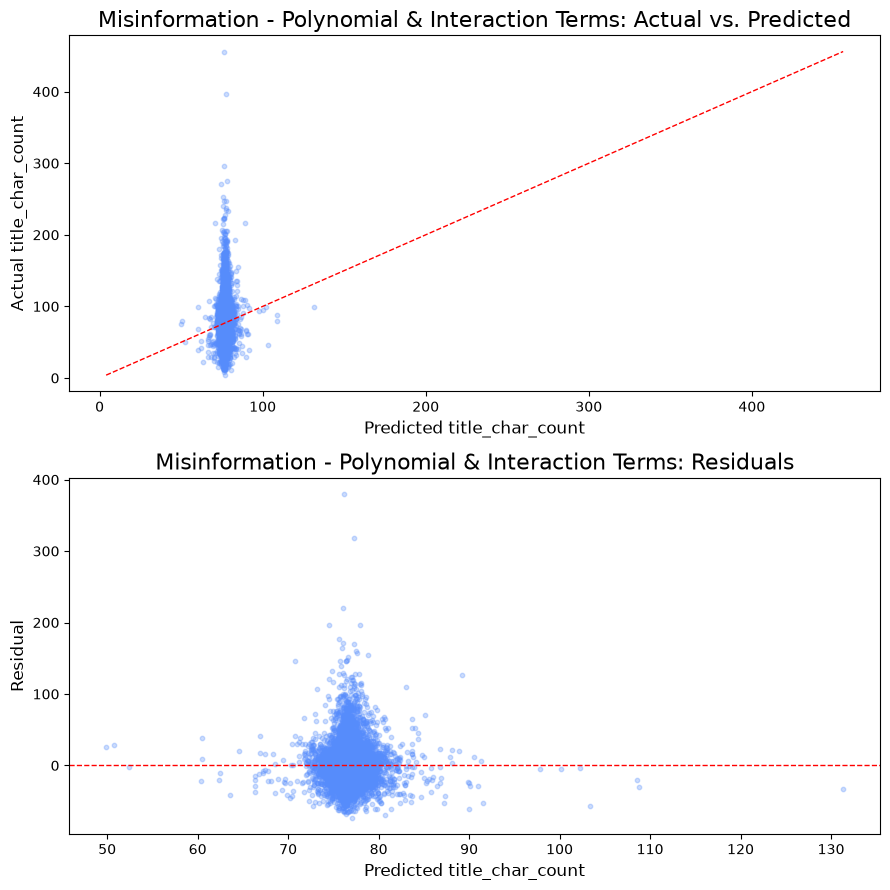

In [183]:
# Compare all three models, and inspect residuals for the final model
comparison = pd.DataFrame(results).set_index("model")
print(comparison)

y_pred_final = model_3.predict(X_test_3)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(2, 1, figsize=(9, 9))
axes[0].scatter(y_pred_final, y_test, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Predicted title_char_count")
axes[0].set_ylabel("Actual title_char_count")
axes[0].set_title("Misinformation - Polynomial & Interaction Terms: Actual vs. Predicted")

axes[1].scatter(y_pred_final, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted title_char_count")
axes[1].set_ylabel("Residual")
axes[1].set_title("Misinformation - Polynomial & Interaction Terms: Residuals")

for ax in axes:
    ax.title.set_fontsize(16)
    ax.xaxis.label.set_fontsize(12)
    ax.yaxis.label.set_fontsize(12)

plt.tight_layout()
plt.show()


**Dataset 3 takeaways:** none of the text-based continuous predictors show meaningful
multicollinearity (VIFs stay in the low single digits), so Model 2 is identical to
Model 1 here - nothing gets dropped, which is itself a useful contrast to the two
network-traffic datasets where VIF forced real feature elimination. The polynomial +
interaction terms in Model 3 make little difference either way. That is a legitimate
finding rather than a modeling failure: headline length is a genuinely different quantity
from body-text statistics, so most of its variation is left unexplained by these
features, and no amount of extra nonlinear structure manufactures a relationship that
was not there in the first place.

# Conclusion & Observations

All three datasets went through the same regression workflow: pick a continuous
target, pick or engineer a categorical feature, fit a main-effects baseline, check
Variance Inflation Factor for multicollinearity among the continuous predictors, refit
after removing the worst offenders, and then add a small, deliberately limited set of
polynomial and interaction terms on top of the reduced feature set. Datasets 1 and 3
were run end-to-end on their full cleaned data (37,809 and 63,073 rows); Dataset 2's
regression section follows the same already-validated pipeline as Dataset 1 but is
sized for a machine with more memory than a lightweight sandbox to load 885 MB of raw
flow data across 8 files.

The malware/ransomware dataset showed textbook multicollinearity: Total Backward
Packets carried a VIF near 292 (chiefly redundant with Total Length of Bwd Packets, VIF
~254), a direct consequence of how CICFlowMeter derives its columns rather than anything
specific to this traffic. Dropping the redundant feature (Model 2) actually made raw
prediction *worse* than the collinear baseline (R^2 0.380 vs. 0.454) - a reminder that
VIF flags a coefficient-interpretation problem, not a prediction problem, and that a
"cleaner" model is not automatically a more accurate one. Adding back a small,
deliberately limited polynomial + interaction expansion of two well-behaved "Mean"-style
features (Model 3) more than closed that gap, reaching the best R^2 of the three models
(0.510) - the earlier expansion attempt covered every remaining feature and overfit
badly (a strongly negative held-out R^2), which is why the final version restricts the
expansion to two features rather than all of them.

The misinformation dataset was a useful contrast: its continuous predictors (derived
from article-body text statistics) showed essentially no multicollinearity (VIFs all
under 2.1 on the full 63,073-row dataset), so the VIF step changed nothing, and the
polynomial + interaction terms moved R^2 only from 0.109 to 0.113. That is a legitimate
finding rather than a modeling failure - headline length is simply not well explained by
these particular body-text features, and no amount of added nonlinear structure
manufactured a relationship that was not there in the first place.

Across the datasets, the exercise underlines lessons that only showed up by actually
comparing held-out performance rather than assuming it: check multicollinearity before
trusting individual coefficients, but do not assume that fixing it will also improve
prediction; and when adding polynomial or interaction terms, expand a small, well-chosen
subset of features rather than every remaining one - an unrestricted degree-2 expansion
of several heavy-tailed count/total features produced a badly overfit model with
strongly negative held-out R^2 during development, while the same technique applied to
two well-behaved features was stable and, for the malware data, the best-performing
model of the three.